# LAB 5 - Visualisasi Data dengan Matplotlib

## Praktikum Analitik dan Visualisasi Data

Notebook ini membahas visualisasi data dasar menggunakan **Matplotlib** pada dataset **Olist E-Commerce**.  
Fokus praktikum meliputi:
- Line plot
- Bar chart
- Scatter plot
- Histogram
- Customizing plots
- Subplots dan layout
- Interpretasi insight bisnis

---
### Petunjuk
1. Pastikan dataset berada pada folder `../dataset/`
2. Jalankan cell secara berurutan
3. Setiap visualisasi wajib diikuti interpretasi hasil


## 1. Tujuan Praktikum

Setelah menyelesaikan praktikum ini, mahasiswa diharapkan mampu:

1. Menggunakan library **Matplotlib** untuk membuat berbagai jenis visualisasi data dasar.
2. Menghasilkan visualisasi berupa:
   - Line chart (tren waktu)
   - Bar chart (perbandingan kategori)
   - Scatter plot (hubungan variabel)
   - Histogram (distribusi data)
3. Melakukan **customization visualisasi** (judul, label, warna, legend, grid) agar grafik mudah dipahami.
4. Menggunakan **subplot** untuk menampilkan beberapa grafik dalam satu tampilan.
5. Menginterpretasikan hasil visualisasi untuk mengidentifikasi:
   - Tren
   - Pola
   - Hubungan antar variabel
   - Anomali data
6. Menghubungkan hasil visualisasi dengan **insight bisnis pada dataset e-commerce**.


## 2. Import Library

Pada tahap ini, kita mengimpor library yang dibutuhkan untuk membaca data, mengolah data, dan membuat visualisasi.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Optional: style visualisasi agar lebih rapi
plt.style.use('seaborn-v0_8')

# Menampilkan semua kolom jika diperlukan
pd.set_option('display.max_columns', None)

## 3. Load Dataset

Dataset yang digunakan:
- `olist_orders_dataset.csv`
- `olist_order_items_dataset.csv`
- `olist_products_dataset.csv`

> Pastikan file berada di folder `../dataset/`


In [2]:
orders_path = '../dataset/olist_orders_dataset.csv'
items_path = '../dataset/olist_order_items_dataset.csv'
products_path = '../dataset/olist_products_dataset.csv'

df_orders = pd.read_csv(orders_path)
df_items = pd.read_csv(items_path)
df_products = pd.read_csv(products_path)

print("df_orders:", df_orders.shape)
print("df_items:", df_items.shape)
print("df_products:", df_products.shape)

df_orders: (99441, 8)
df_items: (112650, 7)
df_products: (32951, 9)


## 4. Preview Data

Lakukan pengecekan awal terhadap struktur data.


In [3]:
display(df_orders.head())
display(df_items.head())
display(df_products.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## 5. Data Preparation

Pada tahap ini dilakukan:
1. Konversi kolom tanggal menjadi format datetime
2. Membuat kolom bulan transaksi
3. Menggabungkan dataset agar analisis lebih bermakna


In [4]:
# Konversi kolom datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

# Membuat kolom bulan
df_orders['order_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

# Merge dataset
df = df_orders.merge(df_items, on='order_id', how='inner')
df = df.merge(df_products, on='product_id', how='left')

print("Shape data gabungan:", df.shape)
display(df.head())

Shape data gabungan: (112650, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


## 6. Cek Missing Values

Pengecekan missing values dilakukan agar kita memahami kualitas data sebelum divisualisasikan.


In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0].head(20)

order_delivered_customer_date    2454
product_photos_qty               1603
product_description_lenght       1603
product_name_lenght              1603
product_category_name            1603
order_delivered_carrier_date     1194
product_width_cm                   18
product_height_cm                  18
product_length_cm                  18
product_weight_g                   18
order_approved_at                  15
dtype: int64

## 7. Visualisasi 1 - Line Chart
### Trend Jumlah Order per Bulan

Line chart digunakan untuk melihat perkembangan jumlah order dari waktu ke waktu.


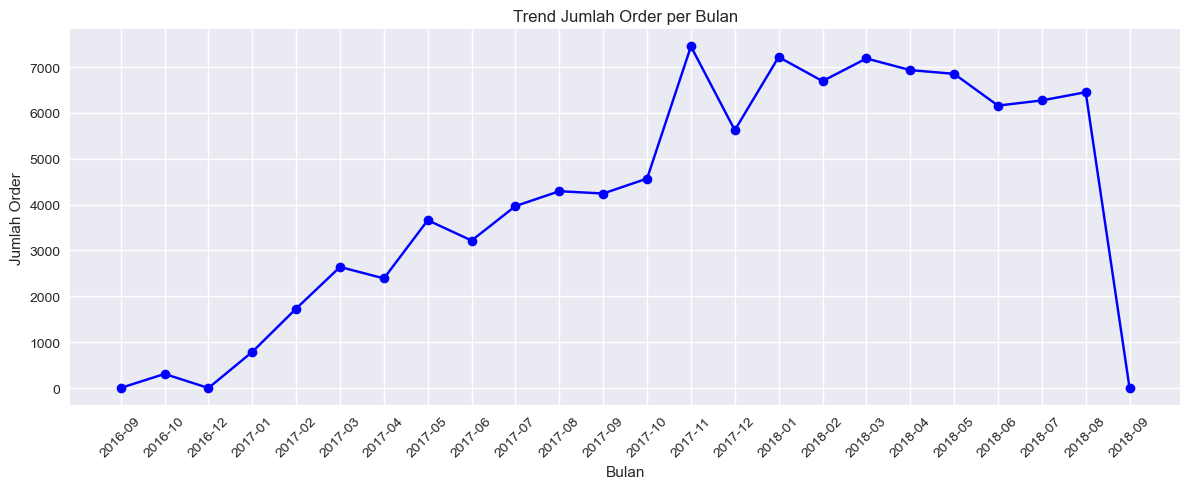

In [6]:
orders_per_month = df.groupby('order_month')['order_id'].nunique()

plt.figure(figsize=(12, 5))
plt.plot(orders_per_month.index.astype(str), orders_per_month.values, marker='o', color='blue')

plt.title('Trend Jumlah Order per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretasi
Tuliskan interpretasi Anda pada bagian ini:

- Apakah terjadi tren kenaikan atau penurunan?
- Apakah terdapat lonjakan pada periode tertentu?
- Apa kemungkinan penyebab pola tersebut dalam konteks e-commerce?


## 8. Visualisasi 2 - Bar Chart
### Top 10 Kategori Produk Terbanyak

Bar chart digunakan untuk membandingkan jumlah order antar kategori produk.


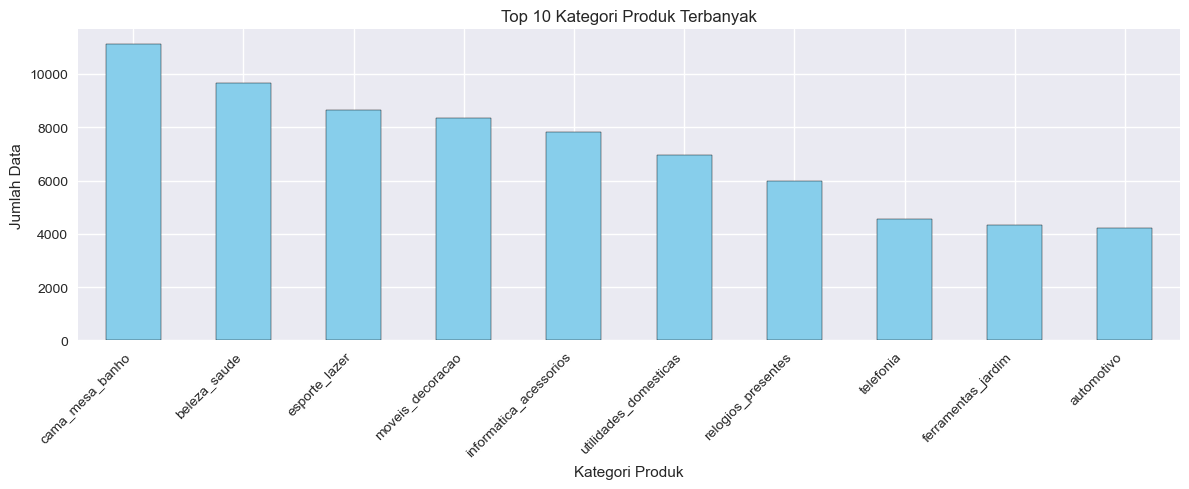

In [7]:
top_category = df['product_category_name'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_category.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Top 10 Kategori Produk Terbanyak')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretasi
Tuliskan interpretasi Anda pada bagian ini:

- Kategori apa yang paling dominan?
- Apa arti dominasi kategori tersebut bagi strategi bisnis?
- Bagaimana kategori ini bisa memengaruhi stok dan promosi?


## 9. Visualisasi 3 - Scatter Plot
### Hubungan Harga Produk dan Biaya Pengiriman

Scatter plot digunakan untuk melihat hubungan antara dua variabel numerik.


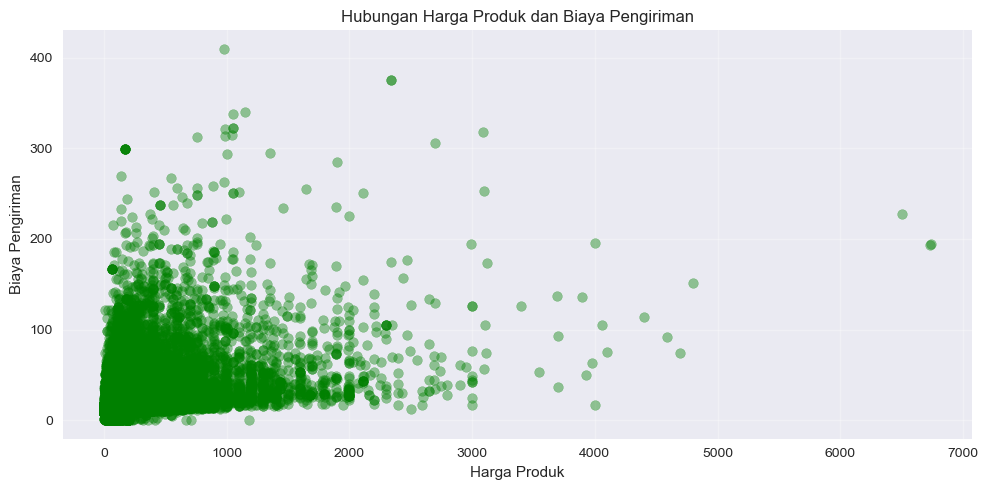

In [8]:
plt.figure(figsize=(10, 5))
plt.scatter(df['price'], df['freight_value'], alpha=0.4, color='green')

plt.title('Hubungan Harga Produk dan Biaya Pengiriman')
plt.xlabel('Harga Produk')
plt.ylabel('Biaya Pengiriman')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretasi
Tuliskan interpretasi Anda pada bagian ini:

- Apakah terdapat hubungan antara harga produk dan biaya pengiriman?
- Apakah ada outlier?
- Apa insight bisnis yang dapat diambil dari pola tersebut?


## 10. Visualisasi 4 - Histogram
### Distribusi Harga Produk

Histogram digunakan untuk melihat distribusi data numerik.


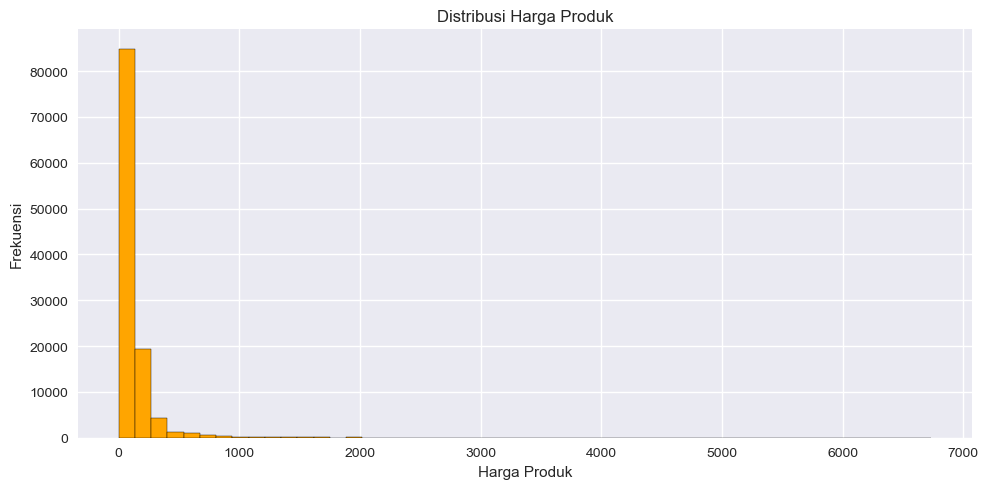

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(df['price'].dropna(), bins=50, color='orange', edgecolor='black')

plt.title('Distribusi Harga Produk')
plt.xlabel('Harga Produk')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

### Interpretasi
Tuliskan interpretasi Anda pada bagian ini:

- Apakah distribusi harga cenderung normal atau miring?
- Apakah mayoritas produk berada pada rentang harga rendah, sedang, atau tinggi?
- Apa implikasi distribusi ini terhadap segmentasi pasar?


## 11. Customizing Plot
### Contoh Kustomisasi Visualisasi

Pada tahap ini, kita menambahkan elemen visualisasi agar grafik lebih informatif.


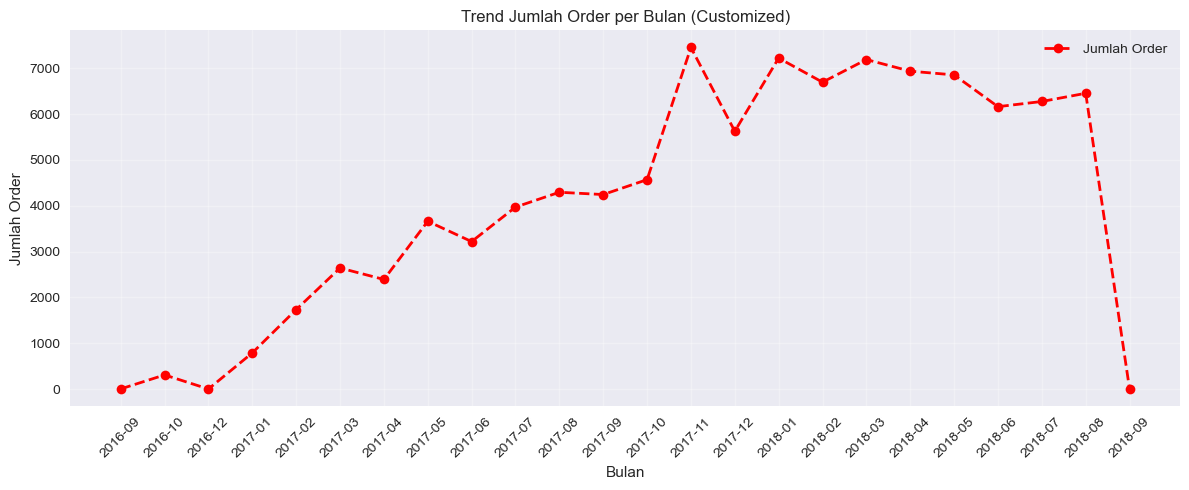

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    orders_per_month.index.astype(str),
    orders_per_month.values,
    color='red',
    linestyle='--',
    marker='o',
    linewidth=2,
    label='Jumlah Order'
)

plt.title('Trend Jumlah Order per Bulan (Customized)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Tugas Kecil
Ubah sendiri elemen berikut:
- warna garis
- jenis marker
- ukuran figure
- style grid
- judul visualisasi


## 12. Subplots dan Layout
### Menampilkan Beberapa Grafik dalam Satu Figure

Subplot digunakan agar beberapa visualisasi dapat ditampilkan sekaligus dalam satu halaman analisis.


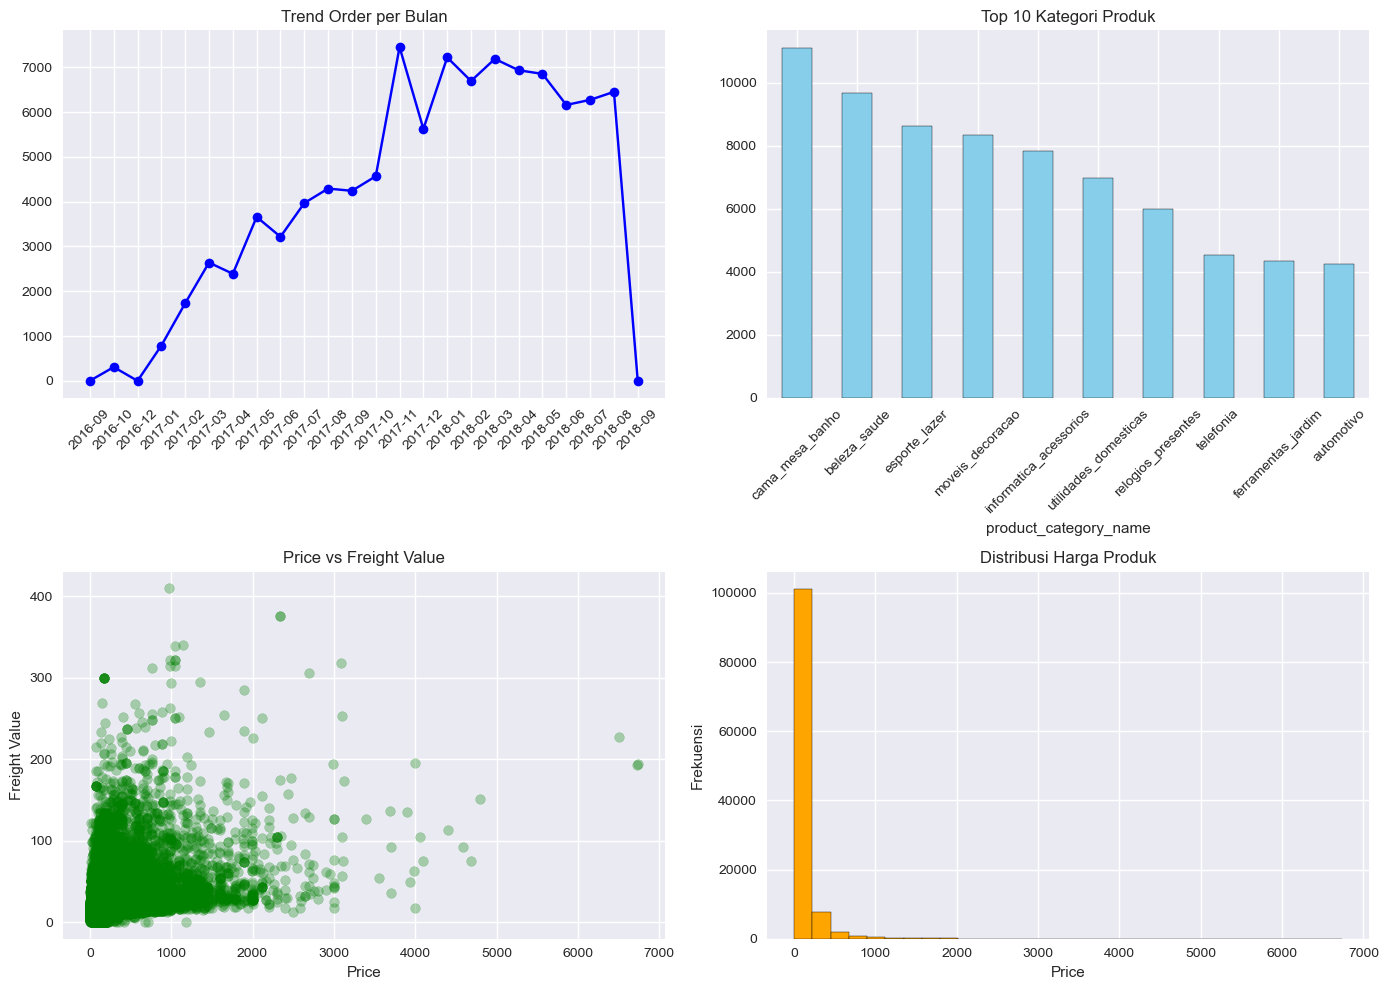

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Line chart
ax[0, 0].plot(orders_per_month.index.astype(str), orders_per_month.values, color='blue', marker='o')
ax[0, 0].set_title('Trend Order per Bulan')
ax[0, 0].tick_params(axis='x', rotation=45)

# 2. Bar chart
top_category.plot(kind='bar', ax=ax[0, 1], color='skyblue', edgecolor='black')
ax[0, 1].set_title('Top 10 Kategori Produk')
ax[0, 1].tick_params(axis='x', rotation=45)

# 3. Scatter plot
ax[1, 0].scatter(df['price'], df['freight_value'], alpha=0.3, color='green')
ax[1, 0].set_title('Price vs Freight Value')
ax[1, 0].set_xlabel('Price')
ax[1, 0].set_ylabel('Freight Value')

# 4. Histogram
ax[1, 1].hist(df['price'].dropna(), bins=30, color='orange', edgecolor='black')
ax[1, 1].set_title('Distribusi Harga Produk')
ax[1, 1].set_xlabel('Price')
ax[1, 1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## 13. Analisis dan Pembahasan

Pada bagian ini, mahasiswa diminta menyusun pembahasan berdasarkan visualisasi yang telah dibuat.

### Panduan Pembahasan
1. Jelaskan tren jumlah order per bulan.
2. Jelaskan kategori produk yang paling dominan.
3. Jelaskan hubungan harga dengan biaya pengiriman.
4. Jelaskan distribusi harga produk.
5. Hubungkan seluruh hasil visualisasi dengan konteks bisnis e-commerce.

> Jangan hanya mendeskripsikan grafik. Jelaskan arti analitisnya.


## 14. Latihan Mandiri

Kerjakan latihan berikut:
1. Buat line chart untuk rata-rata harga produk per bulan.
2. Buat bar chart untuk 10 kategori dengan rata-rata harga tertinggi.
3. Buat scatter plot antara `price` dan `order_item_id`.
4. Buat histogram untuk `freight_value`.
5. Buat 1 figure berisi 4 subplot baru dengan tema berbeda.


## 15. Kesimpulan

Tuliskan kesimpulan praktikum:
- Apa yang dipelajari?
- Visualisasi apa yang paling efektif?
- Insight bisnis apa yang paling penting?
